# Zufallszahlen Erzeugen

## Übungsblatt

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy

### Aufgabe 1: Allgemeine Gleichverteilung

Implementiere eine Funktion `random_uniform(a, b, n, seed)`, die `n` Zufallszahlen gleichverteilt im Intervall $[a, b)\in\mathbb R$ mithilfe der Middle-Square-Methode mit 10-stelligen Zahlen erzeugt.

Vorgehen
- Übernehme die Middle-Square-Methode aus der Vertiefung und passe sie so an, dass sie 10-stellige Zahlen erzeugt.
- Skaliere die erzeugten Zahlen zuerst so, dass sie im Intervall $[0, 1)$ liegen, siehe Vertiefung.
- Skaliere die Zahlen dann so, dass sie im Intervall $[a, b)$ liegen. (Mit $b-a$ skalieren und um $a$ verschieben.)

Teste die Funktion, indem du 10'000 Zufallszahlen im Intervall $[-2, 5)$ erzeugst und in einem Histogramm darstellst. Prüfe von Auge, ob die Zahlen wirklich gleichverteilt im Intervall $[-2, 5)$ liegen.

### Aufgabe 2: Normalverteilung würfeln

Nutze den Random Genarator von NumPy, um 10'000 Zufallszahlen aus einer Normalverteilung ([`rng.normal`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.normal.html)) mit Erwartungswert $4$ und Standardabweichung $2$ zu erzeugen. Stelle die Häufigkeitsdichte der erzeugten Zahlen in einem Histogramm mit 60 bins dar.

Weshalb 60 bins? Hier habe ich die [Freedman-Diaconis Faustregel](https://en.wikipedia.org/wiki/Freedman%E2%80%93Diaconis_rule) benutzt. Eine gute Binbreite ist $w = 2\cdot IQR\cdot n^{-1/3}$, wobei $IQR$ der Interquartilsabstand ist. Die Anzahl bins ist dann

$$
    n_\mathrm{bins} = \frac{\left(\max(x) - \min(x)\right) n^{1/3}}{2\cdot\mathrm{IQR}}
$$

Die Option `bins` von `plt.hist` kann übrigens auch ein String sein, der eine der Methoden angibt, wie die Anzahl der bins bestimmt werden soll. Zum Beispiel `bins='fd'` für die Freedman-Diaconis Faustregel. Siehe Details dazu hier: https://numpy.org/doc/stable/reference/generated/numpy.histogram_bin_edges.html.

### Aufgabe 3: Zahlenlotto

#### a) Lotto Simulation

Schreibe eine Funktion `lotto_ziehen(rng)`, die mit einem gegebenen Zufallszahlengenerator `rng` 6 verschiedene Zahlen zwischen 1 und 42 zieht und zusätzlich eine Glückszahl zwischen 1 und 6. Der Rückgabewert soll ein `tuple` mit den 6 Lottozahlen in aufsteigender Reihenfolge als `set` und der Glückszahl als `ìnt` sein.

> 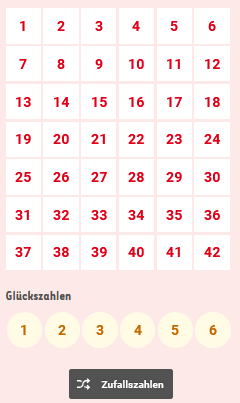
> 
> Swiss Lotto | Einzeltipps spielen | Swisslos. (o. J.). Abgerufen 27. Januar 2026, von https://www.swisslos.ch/de/konto/spielkonto/uebersicht.html


#### b) Bewertung

Schreibe nun eine Funktion `lotto_bewerten(tipp, ziehung)`, die einen Tipp (`tuple[set[int], int]`) und eine Ziehung (`tuple[set[int], int]`) als Argumente entgegennimmt und die Anzahl der Übereinstimmungen zurückgibt. Dabei soll die Glückszahl halb (0.5) gezählt werden. Z.B.: Stimmen 3 Lottozahlen überein und die Glückszahl auch, so gibt die Funktion 3.5 zurück.

Hinweis: Nutze die Methode [`set.intersection`](https://www.geeksforgeeks.org/intersection-function-python/).

#### c) Simulation

**1.** Simuliere nun die Ergebnisse von 50 Ziehungen mit dem immer gleichen Tipp. Schreibe dazu eine Funktion `lotto_simulieren(tipp, n, seed=None)`, die `n` Ziehungen simuliert, den Tipp auswertet und alle Bewertungen als Array zurückgibt. Nutze dazu die Funktion `lotto_ziehen` aus Aufgabe 2a) und die Funktion `lotto_auswerten` aus Aufgabe 2b). Die Funktion soll zuerst einen Zufallszahlengenerator mit dem gegebenen `seed` initialisieren.

Zum Überprüfen: mit dem Tipp `{4, 18, 26, 27, 28, 29}`, der Glückszahl `6` und dem Seed `42` sollte die Summe der Bewertungen `50.5` ergeben. 

#### d) Erfolg? (optional)

Schreibe eine Funktion `ziehungen_bis_zum_sechser(tipp, bewertung, seed=None)`, die simuliert, wie viele Ziehungen nötig sind, um eine 6 im Lotto zu haben.

Mit dem Tipp von Teil c) und dem Seed `42` sollte es 14'556'468 Ziehungen brauchen, um eine 6 im Lotto zu haben. (Die Simulation dauerte bei mir ca. 4 Minuten.)

**Vorsicht:** Diese Funktion kann grundsätzlich unendlich lange laufen, weil Erfolg nicht garantiert ist. Zur Vermeidung von Endlosschleifen könnte man z.B. eine maximale Anzahl an Ziehungen (`maxiter`) festlegen.

### Aufgabe 4: Diskrete Zufallsvariable

In einem Blutanalyse-Labor werden 8 verschiedene Bluttests durchgeführt. Die Statistik über das letzte Jahr besagt, dass die Tests, die wir hier einfach mit Buchstaben bezeichnen, folgende relative Häufigkeiten haben:

Im Folgenden gehen wir davon aus, dass die Tests unabhängig voneinander auftreten und dass die Häufigkeiten konstant sind. Entsprechend können wir die Wahscheinlichkeiten der Tests gleich deren relativen Häufigkeiten setzen. 

#### a) Wahrscheinlichkeiten darstellen

Stelle die Wahrscheinlichkeitsverteilung der Zufallsvariable $T$ dar, die den Test-Typ angibt. Nutze dazu ein Säulendiagramm ([`plt.bar`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html)).

#### b) Tests simulieren

Für die Planung einer neuen automatisierten Analyse-Anlage soll nun ein dynamisches Simulationsmodell mit zufällig auftretenden Test-Aufträgen gefüttert werden. Schreibe eine Funktion `generate_tests(n, seed)`, die eine Anzahl `n` Tests zufällig erzeugt und als Array zurückgibt. Die Tests sollen dabei als Buchstaben von A bis H repräsentiert werden und der Wahrscheinlichkeitsverteilung aus der Statistik in a) folgen. Der Parameter `seed` soll den Standard-Zufallsgenerator von NumPy initialisieren.

#### c) Resultate auswerten

Ziehe mithilfe der Funktion aus b) 500 zufällige Tests und stelle die relativen Häufigkeiten in einem Säulendiagramm dar.

Dazu hast du drei Möglichkeiten:
- Verwende die Klasse [`collections.Counter`](https://docs.python.org/3/library/collections.html#collections.Counter), um die Häufigkeiten der Tests zu bestimmen, und die Funktion [`plt.bar`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html) für das Säulendiagramm.
- Vewende eine Pandas Series, um die Häufigkeiten der Tests zu bestimmen, und die Methode [`Series.plot`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.plot.html) für das Säulendiagramm.
- Verwende direkt [`sns.countplot`](https://seaborn.pydata.org/generated/seaborn.countplot.html) oder [`sns.histplot`](https://seaborn.pydata.org/generated/seaborn.histplot.html) von Seaborn.

### Aufgabe 5: Inversionsmethode für kontinuierliche Zufallsvariablen (optional)

Mithilfe der [Inversionsmethode](https://de.wikipedia.org/wiki/Inversionsmethode) können Zufallszahlen aus einer beliebigen Wahrscheinlichkeitsverteilung erzeugt werden. Dazu zieht man Zahlen $u$ aus der Gleichverteilung $U(0,1)$ und wendet die Umkehrfunktion der kumulativen Verteilungsfunktion $F$ der gewünschten Verteilung darauf an: $x = F^{-1}(u)$. Dieses Diagramm zeigt das Prinzip:

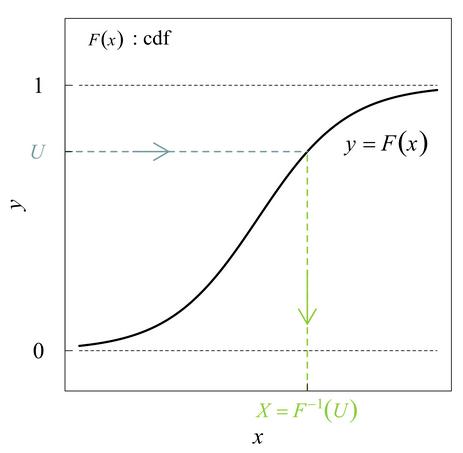

[Ta2o - Eigenes Werk](https://de.wikipedia.org/wiki/Inversionsmethode#/media/Datei:Inversion_method2.svg), [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0), via Wikimedia Commons

- ["Inversionsmethode" - Wikipedia](https://de.wikipedia.org/wiki/Inversionsmethode)

#### Theorie

Die kumulative Verteilungsfunktion $F(x)$ (engl. *cumulative distribution function*, CDF) gibt die Wahrscheinlichkeit an, dass eine Zufallsvariable $X$ einen Wert kleiner oder gleich $x$ annimmt, also

$$ F(x) = P(X \leq x) $$

Daher ist $F(x)$ das Integral der [Wahrscheinlichkeitsdichte](https://de.wikipedia.org/wiki/Wahrscheinlichkeitsdichtefunktion) $f(x)$ (engl. *probability density function*, PDF):

$$ F(x) = \int_{-\infty}^x f(x') \,dx' $$

Die Umkehrfunktion $F^{-1}(u)$ ordnet nun jeder Zahl $u \in [0,1)$ den Wert $x$ zu, für den $F(x) = u$ gilt.

#### Vorgehen

Die Inversionsmethode funktioniert also so:

1. Ziehe eine Zahl $u$ aus der Gleichverteilung $U(0,1)$.
2. Berechne $x = F^{-1}(u)$. $x$ ist nun eine Zufallszahl zur gewünschten Wahrscheinlichkeit $F(x)$.

#### Auftrag

In dieser Übung sollen Zufallszahlen der [Beta-Verteilung](https://de.wikipedia.org/wiki/Beta-Verteilung) erzeugt werden. Die Wahrscheinlichkeitsdichte der Beta-Verteilung kann mithilfe der Funktion [`scipy.stats.beta.pdf`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.beta.html) berechnet werden. Wir gehen so vor:

- Die kumulative Verteilungsfunktion $F(x)$ wird mit numerischer Integration an 100 Punkten berechet.
- Daraus wird eine Interpolationsfunktion erstellt, die $F(x)$ für beliebige $x$ berechnen kann.
- Diese wird anschliessend benutzt, um die Umkehrung $F^{-1}(u)$ numerisch zu berechnen, indem die Gleichung $F(x) = u$ nach $x$ gelöst wird.
- Zum Schluss wird alles zusammengesetzt, um aus einer gleichvereilten Zufallszahl $u$ eine Zufallszahl $x$ aus der Beta-Verteilung zu erzeugen.


#### a) Wahrscheinlichkeitsdichte der Beta-Verteilung berechnen und darstellen

Die Beta-Verteilung ist definiert für $x \in [0, 1]$ und hat zwei Parameter $\alpha$ und $\beta$. Die Wahrscheinlichkeitsdichte $f(x)$ kann mit [`scipy.stats.beta.pdf`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.beta.html) berechnet werden.

Berechne `pdf = f(x)` für $\alpha = 2$ und $\beta = 5$ an 100 Punkten im Intervall $x \in [0, 1]$ und stelle diese in einem Diagramm dar.

- ["Betaverteilung" - Wikipedia](https://de.wikipedia.org/wiki/Beta-Verteilung)

#### b) Verteilungsfunktion der Beta-Verteilung numerisch berechnen

Schreibe eine Funktion `F(x, alpha, beta)`, welche die kumulative Verteilungsfunktion der Beta-Verteilung numerisch berechnet. Da es sich um das Integral

$$ F(x) = \int_0^x f(x') \;\mathrm{d}x' $$

handelt, sollst du dazu die passende Funktion aus dem Modul [`scipy.integrate`](https://docs.scipy.org/doc/scipy/reference/integrate.html) verwenden.

Benutze deine Funktion, um `cdf = F(x)` für $\alpha = 2$ und $\beta = 5$ an 100 Punkten im Intervall $x \in [0, 1]$ zu berechnen und stelle diese in einem Diagramm dar.

#### c) Interpolationsfunktion der Verteilungsfunktion

Erstelle eine lineare Interpolationsfunktion der berechneten Werte `cdf` mithilfe der passenden Funktion aus dem Modul [`scipy.interpolate`](https://docs.scipy.org/doc/scipy/reference/interpolate.html). Nenne diese `F_interp`.

Teste deine Funktion mit dem Wert $x = 0.5$. Dies soll $0.8905532623114158$ ergeben.


#### d) Wahrscheinlichkeitsfunktion invertieren

Nun soll zu jedem $u \in [0,1]$ das $x$ mit $F(x) = u$ gefunden werden, also $x = F^{-1}(u)$.

Schreibe dazu eine Funktion `F_inv(u)`, welche das Newton-Verfahren aus [`scipy.optimize`](https://docs.scipy.org/doc/scipy/reference/optimize.html) und `F_interp(x)` von vorhin nutzt, um die Gleichung $F(x) - u = 0$ zu lösen, und $x$ zurückgibt.

Nutze `x0 = 0.5` als Startwert und erhöhe die maximiale Anzahl an Iterationen auf 1000.

Teste deine Funktion mit dem Wert $u = 0.5$. Dies sollte $F^{-1}(0.5)=0.26446285938954506$ geben.

#### e) Zufallszahlen aus der Beta-Verteilung erzeugen

Schreibe zum Abschluss eine Funktion `random_beta(n, seed=None)`, die $n$ Zufallszahlen aus der Beta-Verteilung erzeugt.

Benutze hierfür den Default Random Generator von NumPy und [`rng.uniform`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.uniform.html), um $n$ zufällige $u$-Werte zu generieren. Diese Werte werden dann mit `F_inv(u)` in $x$-Werte transformiert. Diese Funktion soll ein Array mit den $x$-Werten zurückgeben.

Erzeuge mit dieser Funktion 10'000 Beta-verteilte Zahlen. Stelle die relative Häufigkeit davon in einem Histogramm dar. Benutze hierfür [`plt.hist`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html) mit `density=True` und `bins="fd"` (für die [Freedman-Diaconis Faustegel](https://en.wikipedia.org/wiki/Freedman%E2%80%93Diaconis_rule) zur Bestimmung der Binbreite). Plotte dazu die Wahrscheinlichkeitsdichte $f(x)$ aus a).